# Compare DE calculations by MS Stats (R Package) and Auto-Prot



In [1]:
# import necessary libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# this allows the notebook to run where ever the repo is located
# set repo_root to two levels up from current working directory
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
print(f"Repo root: {repo_root}")

# create output directory for plots
output_dir = os.path.join(repo_root, "output/compare-msstats")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}")


Repo root: /Users/Chimz/Google Drive/Projects/inProgress/10_UCL_DataSci/AP/Auto-Prot


```markdown
# Introduction

This notebook compares differential expression (DE) calculations across three methods: Auto-Prot, Limma (in R) and MS Stats (also an R package). Auto-Prot processes the data using python libraries then calculates DE using Limma. The Limma results here are generated by processing the data in R and estimating DE in R with Limma. MS stats is a separate R package. The R calculations are done by script `autoprot/r_scripts/DE-with-MSstats-Limma.R`. See `docs/compare-DE-methods.md` for info on generating the results that are used in this notebook.

The aims are:
- confirm Auto-Prot performs as expected. This first means generating outputs that are similar to those generated by Limma when used in an R script. Using the same data, do we get similar LFCs and p-values?
- explore impact of imputing on DE results. After confirming Auto-Prot and Limma-in-R produce similar results for the same inputs, compare the outputs of proteins with and without imputation.
- demonstrate impact of using different DE calculations. Compare Auto-Prot output with MS Stats, an R package that uses a different pipeline for processing protein intensities and estimate differential expression.

# Summary

The analysis highlights the following key findings:
- Pairwise comparisons of LFC, raw p-values, and adjusted p-values reveal varying degrees of correlation between the methods.
- Missing data and imputation have a noticeable impact on the results, with imputed values influencing the consistency of DE calculations.
- MSstats appears to apply a stricter correction for adjusted p-values compared to Auto-Prot and Limma, which would have a strong influence on identification of DE genes if using a strict p value cut off

# TLDR
Method choice impacts results - no single method is correct. Best practice involves proper exploration your data, validating results with multiple analyses and ideally experimental validation!

```

# Auto-Prot vs Limma (in R): Log2-transformed data
This is a positive control type of test. Given exactly the same input data, do we get the same results? Is Auto-Prot working as we expect. The figures below confirm Auto-Prot produces the same LFCs, p-values and FDR-adjusted p-values as Limma executed in R.

In [3]:
### First compare R Limma and Auto-Prot on log2-transformed data. This is a positive control type test
# read in the data
# read Auto-Prot results
ap_log2_res_path = os.path.join (repo_root, "output/log2/full_dataset/data/metast_RDEB/metast_RDEB_limma_output.csv")
ap_log2_res = pd.read_csv(ap_log2_res_path)

# rename first column of ap_res to "Protein" (to match ms_res)
ap_log2_res = ap_log2_res.rename(columns={ap_log2_res.columns[0]: "Protein"})
ap_log2_res[ 'logFC' ] = ap_log2_res[ 'logFC' ] * -1  # invert log2FC to match limma direction

# read limma results (from R studio)
limma_log2_res_path = os.path.join (repo_root, "output/compare-msstats/Rstudio-limma-out-log2.csv")
limma_log2_res = pd.read_csv(limma_log2_res_path)
# rename first column of ap_res to "Protein" (to match ms_res)
limma_log2_res = limma_log2_res.rename(columns={limma_log2_res.columns[0]: "Protein"})


## merge the two results dataframes on "Protein"
merged_log2 = pd.merge(limma_log2_res, ap_log2_res, on="Protein", suffixes=('_limma', '_autoprot'))

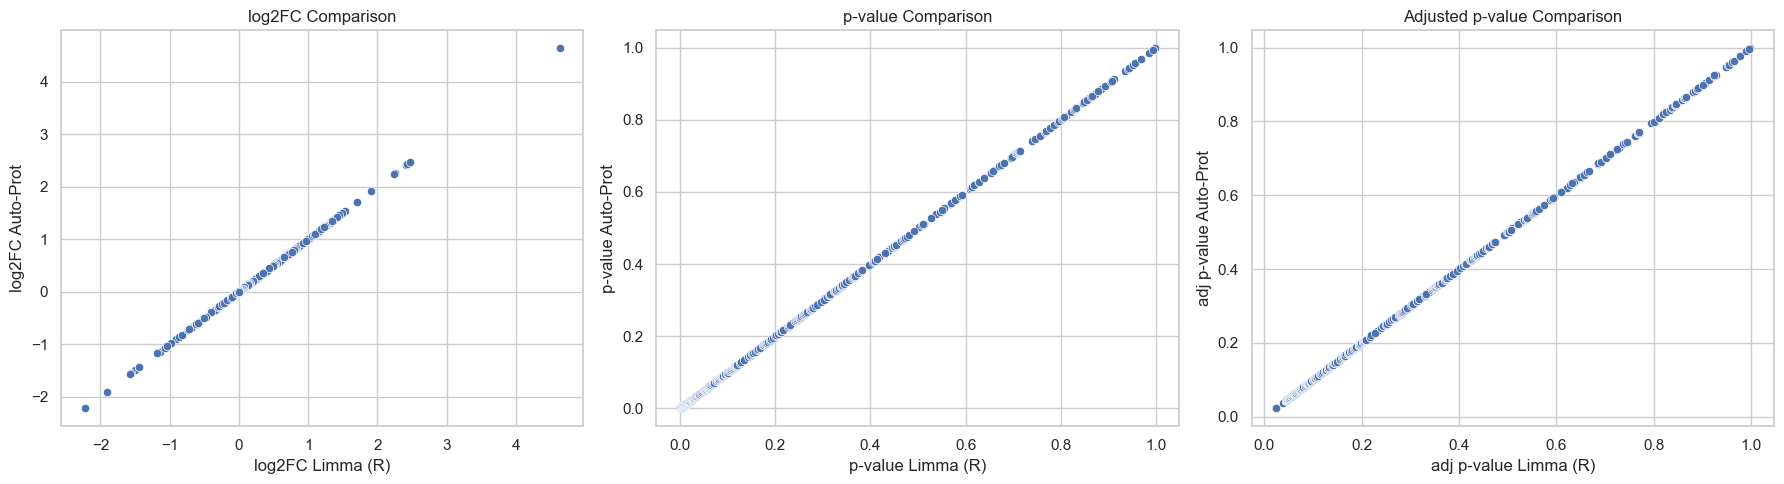

In [4]:
### Plot log2FC, p-value, and adjusted p-value comparisons
def plot_comparison(data, x_col, y_col, title, xlabel, ylabel, ax, xlim=None, ylim=None, color_by_missing=False, plot_corr_line=False):
    sns.scatterplot(data=data, x=x_col, y=y_col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True)
    
    # Add coloring by missing_yes_no if enabled
    if color_by_missing:
        sns.scatterplot(
            data=data, x=x_col, y=y_col, hue='missing_yes_no', ax=ax,
            palette={0: 'blue', 1: 'orange'}, legend='full'
        )
    
    # Add correlation line if enabled
    if plot_corr_line:
        sns.regplot(
            data=data, x=x_col, y=y_col, ax=ax, scatter=False, color='red',
            line_kws={"linestyle": "dashed"}
        )

# set seaborn style
sns.set(style="whitegrid")
# set figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot comparisons
plot_comparison(
    data=merged_log2, x_col='logFC_limma', y_col='logFC_autoprot',
    title='log2FC Comparison', xlabel='log2FC Limma (R)', ylabel='log2FC Auto-Prot',
    ax=axes[0]
)
plot_comparison(
    data=merged_log2, x_col='P.Value_limma', y_col='P.Value_autoprot',
    title='p-value Comparison', xlabel='p-value Limma (R)', ylabel='p-value Auto-Prot',
    ax=axes[1]
)
plot_comparison(
    data=merged_log2, x_col='adj.P.Val_limma', y_col='adj.P.Val_autoprot',
    title='Adjusted p-value Comparison', xlabel='adj p-value Limma (R)', ylabel='adj p-value Auto-Prot',
    ax=axes[2]
)

# adjust layout
plt.tight_layout()
# save figure
plt.savefig(os.path.join(output_dir, "log2fc_pval_adj_pval_comparison_limma_autoprot.png"), dpi=300)
plt.show()
plt.close()


# Auto-Prot vs Limma (in R): Full Pipeline
Now we run both pipelines to the end and compare results. The dataset includes proteins with and without imputed values.

Both pipelines log2-transform the data before applying vsn normalisation. Therefore, proteins without any imputed values (in blue) should be the same in both pipelines, which is what we see.

The proteins with imputed values (orange) have different LFCs, p-values and adjusted p-values. Clearly, choice of imputation has a big impact on your DE results.


In [5]:
### now compare R Limma and Auto-Prot after normalisation and imputation
# read Auto-Prot results
# read Auto-Prot results
ap_imp_res_path = os.path.join (repo_root, "output/imp_GB/full_dataset/data/metast_RDEB/metast_RDEB_limma_output.csv")
ap_imp_res = pd.read_csv(ap_imp_res_path)

# rename first column of ap_res to "Protein" (to match ms_res)
ap_imp_res = ap_imp_res.rename(columns={ap_imp_res.columns[0]: "Protein"})
ap_imp_res[ 'logFC' ] = ap_imp_res[ 'logFC' ] * -1  # invert impFC to match limma direction

# read limma results (from R studio)
limma_imp_res_path = os.path.join (repo_root, "output/compare-msstats/Rstudio-limma-out-imputed.csv")
limma_imp_res = pd.read_csv(limma_imp_res_path)
# rename first column of ap_res to "Protein" (to match ms_res)
limma_imp_res = limma_imp_res.rename(columns={limma_imp_res.columns[0]: "Protein"})


## merge the two results dataframes on "Protein"
merged_imp = pd.merge(limma_imp_res, ap_imp_res, on="Protein", suffixes=('_limma', '_autoprot'))

# proportion missing per protein
prop_missing_path = os.path.join( repo_root, "output/compare-msstats/prop_missing.csv")
prop_missing = pd.read_csv(prop_missing_path)
prop_missing = prop_missing.rename(columns={prop_missing.columns[0]: "Protein"})
prop_missing[ 'proportion_missing'] = round(prop_missing['proportion_missing'], 2)
# if prop missing >0, assign 1, else 0
prop_missing['missing_yes_no'] = np.where(prop_missing['proportion_missing'] > 0, 1, 0)

merged_imp = (
    pd.merge(merged_imp, prop_missing, on="Protein") )

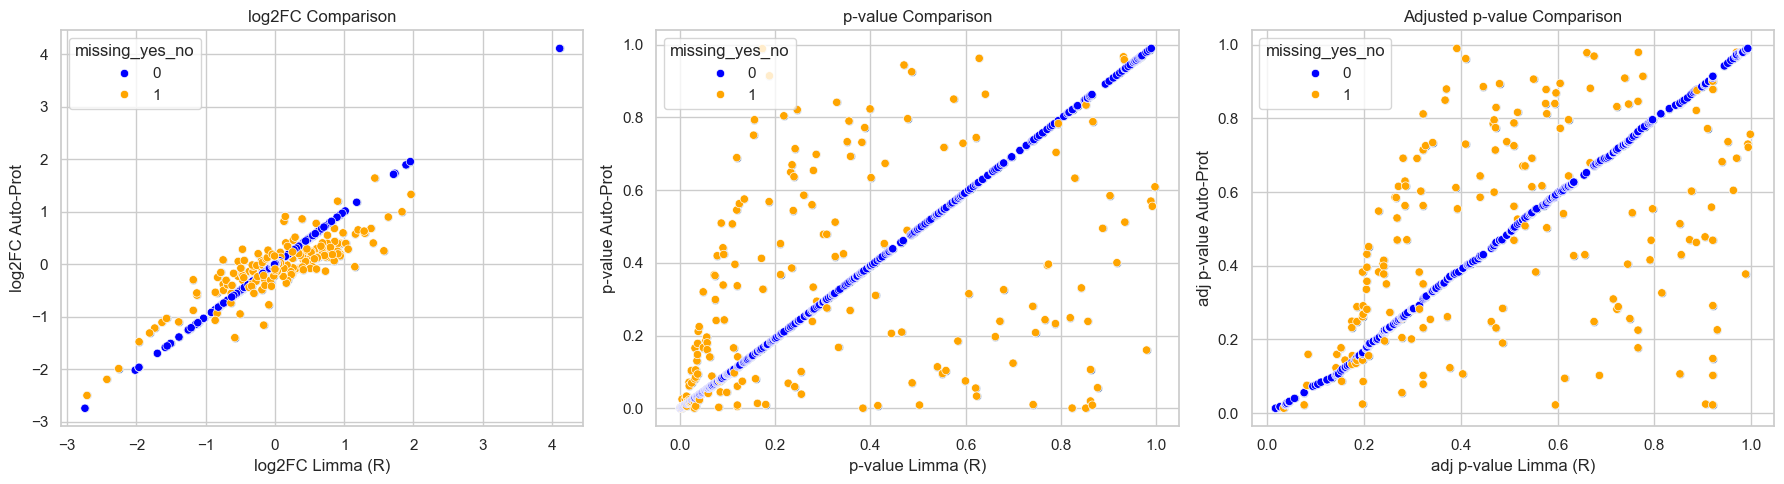

In [6]:
### Plot log2FC, p-value, and adjusted p-value comparisons

# set seaborn style
sns.set(style="whitegrid")
# set figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot comparisons
plot_comparison(
    data=merged_imp, x_col='logFC_limma', y_col='logFC_autoprot',
    title='log2FC Comparison', xlabel='log2FC Limma (R)', ylabel='log2FC Auto-Prot', color_by_missing=True,
    ax=axes[0]
) 

plot_comparison(
    data=merged_imp, x_col='P.Value_limma', y_col='P.Value_autoprot',
    title='p-value Comparison', xlabel='p-value Limma (R)', ylabel='p-value Auto-Prot',color_by_missing=True,
    ax=axes[1]
)

plot_comparison(
    data=merged_imp, x_col='adj.P.Val_limma', y_col='adj.P.Val_autoprot',
    title='Adjusted p-value Comparison', xlabel='adj p-value Limma (R)', ylabel='adj p-value Auto-Prot',color_by_missing=True,
    ax=axes[2]
)

# adjust layout
plt.tight_layout()
# save figure
plt.savefig(os.path.join(output_dir, "log2fc_pval_adj_pval_comparison_limma_autoprot.png"), dpi=300)
plt.show()
plt.close()


## DE Proteins
Do the two methods agree on which proteins are DE?

Although there are lots of differences in general, the methods agree on which proteins are DE. Most of these are proteins without imputed values.

In [7]:
### How many prots are <0.05 in both
# prots < 0.05 in Auto-Prot
ap_sig = merged_imp[ merged_imp['adj.P.Val_autoprot'] < 0.05 ]
print(f"Number of DE proteins in Auto-Prot: {len(ap_sig)}")
# prots < 0.05 in Limma
limma_sig = merged_imp[ merged_imp['adj.P.Val_limma'] < 0.05 ]
print(f"Number of DE proteins in Limma: {len(limma_sig)}")
# prots < 0.05 in both
both_DE = merged_imp[ (merged_imp['adj.P.Val_autoprot'] < 0.05) & (merged_imp['adj.P.Val_limma'] < 0.05) ]
print(f"Number of DE proteins in both: {len(both_DE)}")



Number of DE proteins in Auto-Prot: 28
Number of DE proteins in Limma: 22
Number of DE proteins in both: 22


In [8]:
both_DE['proportion_missing'].value_counts()

proportion_missing
0.00    21
0.05     1
Name: count, dtype: int64

In [9]:
### Read in and merge results
# read MSstats results
ms_res_path = os.path.join (repo_root, "output/compare-msstats/MSstats-out.csv")
ms_res = pd.read_csv(ms_res_path)
ms_res['log2FC'] = ms_res['log2FC'] * -1  # invert impFC to match limma direction

### Compare LFC and adjusted p-values for common proteins
# merge results on "Protein" column
merged_imp = (
    pd.merge(ms_res, merged_imp, on="Protein")
    )

### Comparison of Auto-Prot and MS stats

So we have seen that Auto-Prot performs similarly to a Limma-R pipeline on log-transformed and vsn-normalised data, with less similarity when using different methods for imputing missing values.

Now we look at a completely different package and process for identifying DE proteins: MS Stats.

MSstats provides a comprehensive pipeline for processing raw intensity data, normalizing it, and identifying differentially expressed (DE) proteins. The method includes steps such as data quality control, imputation of missing values, and statistical modeling using linear mixed-effects models. MSstats is particularly robust in handling missing data and applies stringent corrections for multiple testing, resulting in adjusted p-values that are often more conservative compared to other methods. This makes it a valuable tool for ensuring reliable identification of DE proteins in proteomic studies.

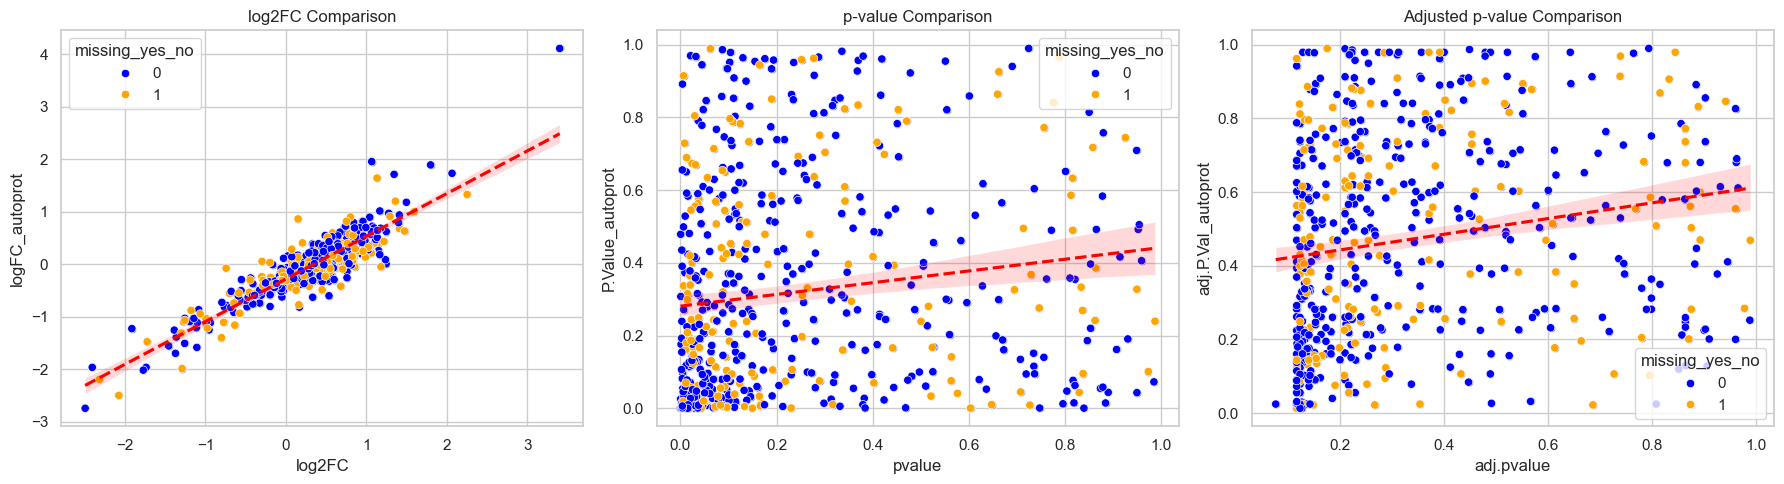

In [10]:
### compare log2FC and p-values and adjusted p-values for MS Stats and Auto-Prot

# set seaborn style
sns.set(style="whitegrid")
# set figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# plot comparisons
plot_comparison(
    data=merged_imp, x_col='log2FC', y_col='logFC_autoprot',
    title='log2FC Comparison', xlabel='log2FC MSstats', ylabel='log2FC Auto-Prot', color_by_missing=True, plot_corr_line=True,
    ax=axes[0]
)

plot_comparison(
    data=merged_imp, x_col='pvalue', y_col='P.Value_autoprot',
    title='p-value Comparison', xlabel='p-value MSstats', ylabel='p-value Auto-Prot', color_by_missing=True,plot_corr_line=True,
    ax=axes[1]
)

plot_comparison(
    data=merged_imp, x_col='adj.pvalue', y_col='adj.P.Val_autoprot',
    title='Adjusted p-value Comparison', xlabel='adj p-value MSstats', ylabel='adj p-value Auto-Prot', color_by_missing=True,plot_corr_line=True,
    ax=axes[2]
)

# adjust layout
plt.tight_layout()
# save figure
plt.savefig(os.path.join(output_dir, "log2fc_pval_adj_pval_comparison_msstats_autoprot.png"), dpi=300)
plt.show()
plt.close()


In [11]:
### How many proteins are DE in both methods?
# prots < 0.05 in Auto-Prot
ap_sig = merged_imp[ merged_imp['adj.P.Val_autoprot'] < 0.05 ]
print(f"Number of DE proteins in Auto-Prot: {len(ap_sig)}")
# prots < 0.05 in MSstats
ms_sig = merged_imp[ merged_imp['adj.pvalue'] < 0.05 ]
print(f"Number of DE proteins in MSstats: {len(ms_sig)}")
# prots < 0.05 in both
both_DE = merged_imp[ (merged_imp['adj.P.Val_autoprot'] < 0.05) & (merged_imp['adj.pvalue'] < 0.05) ]
print(f"Number of DE proteins in both: {len(both_DE)}")

Number of DE proteins in Auto-Prot: 28
Number of DE proteins in MSstats: 0
Number of DE proteins in both: 0


Hmm. the LFC is still correlated between the two methods but the differences are larger and more common in proteins without imputed values. As for the p-values, these are now only weakly related. If applying thresholds to define differential expression, consider using a combination of LFC and adjusted p-value to capture differences meaningful biologically as well as having a lower chance of being false positive.

MS stats is a popular R package for analysing proteomic data. The Auto-Prot pipeline (log2-transform, normalise using vsn, impute with gradient boost, find DEs with Limma) is also fairly standard (although the imputation method is relatively new). The results clearly show that two reasonable, justifiable pipelines can create very different outputs from the same inputs.

The takeaway is simple - think carefully about how you treat your data, understand the pros and cons of different methods, and be cautious in your interpretation. And ideally, validate key findings through further studies!

Happy analysing and please send us any suggestions or questions; contact details on github.


# Compare MS Stats and Limma (in R)
For completeness, compare MS Stats results with results from the Limma-in-R analysis. Just to confirm that differences are due to methods, not to an Auto-Prot quirk. Comparisons look similar to Auto-Prot vs MS Stats.


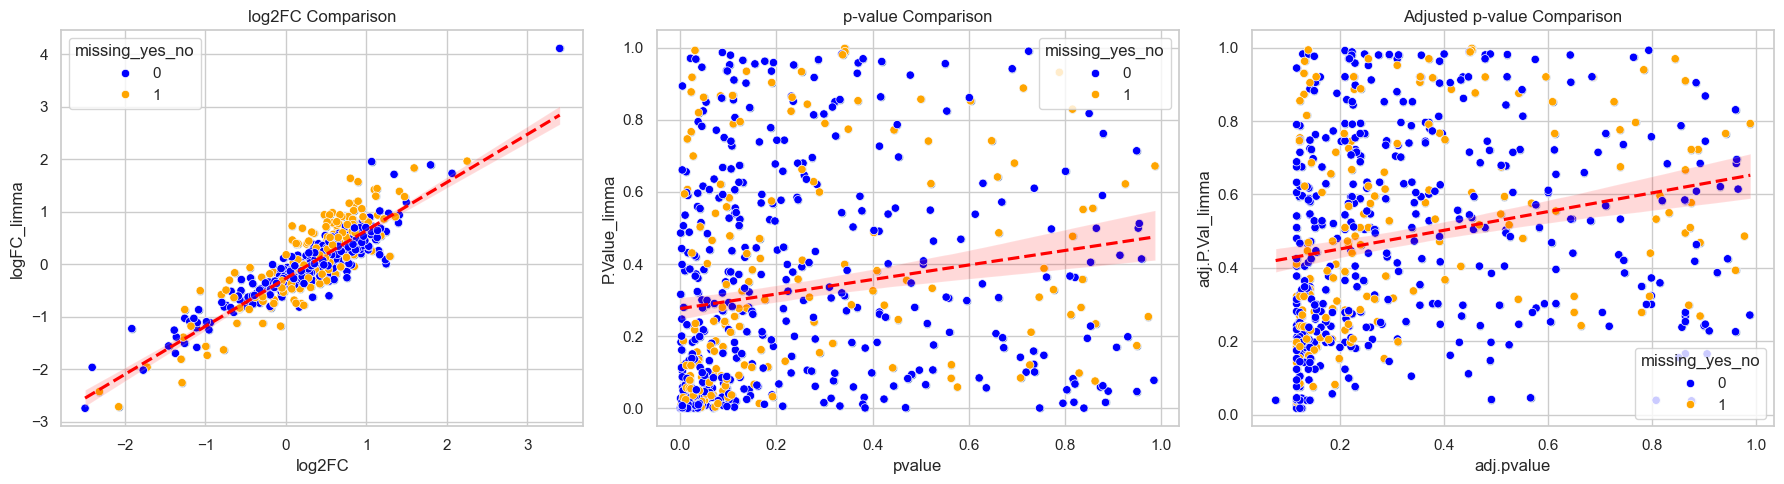

Number of DE proteins in limma-in-R: 22
Number of DE proteins in MSstats: 0
Number of DE proteins in both: 0


In [12]:
### compare log2FC and p-values and adjusted p-values for MS Stats and Limma-in-R

# set seaborn style
sns.set(style="whitegrid")
# set figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# plot comparisons
plot_comparison(
    data=merged_imp, x_col='log2FC', y_col='logFC_limma',
    title='log2FC Comparison', xlabel='log2FC MSstats', ylabel='log2FC Auto-Prot', color_by_missing=True, plot_corr_line=True,
    ax=axes[0]
)

plot_comparison(
    data=merged_imp, x_col='pvalue', y_col='P.Value_limma',
    title='p-value Comparison', xlabel='p-value MSstats', ylabel='p-value Auto-Prot', color_by_missing=True,plot_corr_line=True,
    ax=axes[1]
)

plot_comparison(
    data=merged_imp, x_col='adj.pvalue', y_col='adj.P.Val_limma',
    title='Adjusted p-value Comparison', xlabel='adj p-value MSstats', ylabel='adj p-value Auto-Prot', color_by_missing=True,plot_corr_line=True,
    ax=axes[2]
)

# adjust layout
plt.tight_layout()
# save figure
plt.savefig(os.path.join(output_dir, "log2fc_pval_adj_pval_comparison_msstats_limma.png"), dpi=300)
plt.show()
plt.close()

### How many proteins are DE in both methods?
limma_sig = merged_imp[ merged_imp['adj.P.Val_limma'] < 0.05 ]
print(f"Number of DE proteins in limma-in-R: {len(limma_sig)}")
ms_sig = merged_imp[ merged_imp['adj.pvalue'] < 0.05 ]
print(f"Number of DE proteins in MSstats: {len(ms_sig)}")
both_DE = merged_imp[ (merged_imp['adj.P.Val_limma'] < 0.05) & (merged_imp['adj.pvalue'] < 0.05) ]
print(f"Number of DE proteins in both: {len(both_DE)}")
